# Montessori Census 2022

In [70]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

In [74]:
census_df = pd.read_csv("/home/jovyan/schullandschaft/Montessori Census Map_data.csv", sep='\t', encoding='utf-16')

In [75]:
census_df.columns

Index(['Country ', 'Breitengrad (generiert)', 'Längengrad (generiert)',
       'Count'],
      dtype='object')

In [76]:
!pip install wbgapi country-converter

In [77]:
#import pandas as pd
import wbgapi as wb
import country_converter as coco

# --- 1. Fetch World Bank Data (2022) ---
# 'SP.POP.TOTL' is Total Population
# time=2022 fetches only that year
# mrnev=1 is a fallback to the 'most recent non-empty value' if 2022 is missing
print("Fetching data from World Bank...")
wb_df = wb.data.DataFrame('SP.POP.TOTL', time=2022, labels=True).reset_index()

# Rename columns for clarity (World Bank returns 'SP.POP.TOTL' as the column name)
wb_df = wb_df.rename(columns={'economy': 'ISO3', 'SP.POP.TOTL': 'Population_2022'})

# --- 2. Clean your Census DataFrame ---
# Assuming census_df is already loaded
# Fixing the 'Country ' column (handling the trailing space in your column name)
census_df['Country_Clean'] = census_df['Country '].str.strip()

# --- 3. Convert Country Names to ISO3 Codes ---
# countryconverter handles the Tableau/Common names automatically
print("Converting country names to ISO3...")
cc = coco.CountryConverter()
census_df['ISO3'] = cc.convert(names=census_df['Country_Clean'], to='ISO3')

# --- 4. Merge the Dataframes ---
# We merge on 'ISO3' because it is a universal standard
final_df = pd.merge(
    census_df, 
    wb_df[['ISO3', 'Population_2022']], 
    on='ISO3', 
    how='left'
)

# --- 5. Final Check ---
# Check if any countries failed to match
missing = final_df[final_df['Population_2022'].isna()]['Country_Clean'].unique()
if len(missing) > 0:
    print(f"⚠️ Warning: No population data found for: {missing}")
else:
    print("✅ All countries matched successfully!")

display(final_df.head())

Fetching data from World Bank...
Converting country names to ISO3...
⚠️ Warning: No population data found for: ['Taiwan' 'Martinique']


,Country,Breitengrad (generiert),Längengrad (generiert),Count,Country_Clean,ISO3,Population_2022
0,Zimbabwe,"-19,098","30,047",30,Zimbabwe,ZWE,16069056.0
1,Zambia,"-15,13","25,268",15,Zambia,ZMB,20152938.0
2,Yemen,"15,569","47,793",1,Yemen,YEM,38222876.0
3,Virgin Islands (British),"18,4204","-64,64",1,Virgin Islands (British),VGB,38319.0
4,Viet Nam,"21,75","105,373",80,Viet Nam,VNM,99680655.0


In [78]:
# Manuelle Korrektur nach dem Merge
# Wir suchen die Zeilen über das Feld 'Country_Clean'

# Fix für Taiwan
final_df.loc[final_df['Country_Clean'] == 'Taiwan', 'Population_2022'] = 23890000

# Fix für Martinique
final_df.loc[final_df['Country_Clean'] == 'Martinique', 'Population_2022'] = 370000

# Optional: Falls du noch mehr 'Unknowns' hast, kannst du sie so finden
missing_after_fix = final_df[final_df['Population_2022'].isna()]['Country_Clean'].unique()
print(f"Noch fehlend: {missing_after_fix}")

Noch fehlend: []


In [79]:
final_df.tail()

,Country,Breitengrad (generiert),Längengrad (generiert),Count,Country_Clean,ISO3,Population_2022
149,Antigua and Barbuda,"17,625","-61,786",1,Antigua and Barbuda,ATG,92840.0
150,American Samoa,"-14,3018","-170,7511",2,American Samoa,ASM,48342.0
151,Algeria,"28,6045","2,64",4,Algeria,DZA,45477389.0
152,Albania,"40,654","20,076",2,Albania,ALB,2451636.0
153,Afghanistan,"34,023","65,5267",1,Afghanistan,AFG,40578842.0


In [80]:
final_df['Count_Per_Mil'] = final_df['Count'] / final_df['Population_2022'] * 1000000

In [81]:
final_df.tail()

,Country,Breitengrad (generiert),Längengrad (generiert),Count,Country_Clean,ISO3,Population_2022,Count_Per_Mil
149,Antigua and Barbuda,"17,625","-61,786",1,Antigua and Barbuda,ATG,92840.0,10.771219
150,American Samoa,"-14,3018","-170,7511",2,American Samoa,ASM,48342.0,41.371892
151,Algeria,"28,6045","2,64",4,Algeria,DZA,45477389.0,0.087956
152,Albania,"40,654","20,076",2,Albania,ALB,2451636.0,0.815782
153,Afghanistan,"34,023","65,5267",1,Afghanistan,AFG,40578842.0,0.024643


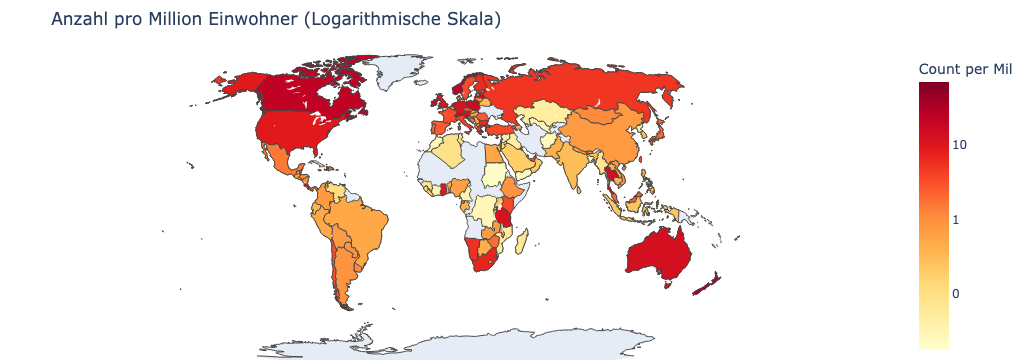

In [82]:
import plotly.express as px
import numpy as np

# 1. Logarithmische Hilfsspalte erstellen
# Wir fügen einen minimalen Wert hinzu (1e-9), falls 'Count_Per_Mil' 0 ist, 
# da log10(0) nicht definiert ist.
final_df['Log_Count'] = np.log10(final_df['Count_Per_Mil'].replace(0, np.nan))

# 2. Choropleth Map erstellen
fig = px.choropleth(
    final_df,
    locations="ISO3",
    color="Log_Count",             # Wir färben basierend auf dem Log-Wert
    hover_name="Country_Clean",
    hover_data={
        "Log_Count": False,        # Den Log-Wert im Hover verstecken
        "Count_Per_Mil": ":.2f",   # Den echten Wert schön formatiert anzeigen
        "ISO3": True
    },
    color_continuous_scale="YlOrRd",
    title="Anzahl pro Million Einwohner (Logarithmische Skala)",
    labels={'Log_Count': 'log10(Count)'}
)

# 3. Die Legende anpassen (Ticks verschönern)
# Hier tricksen wir ein bisschen, damit die Legende wieder echte Zahlen zeigt
# anstatt der Log-Werte (z.B. 10, 100, 1000)
max_log = int(np.ceil(final_df['Log_Count'].max()))
min_log = int(np.floor(final_df['Log_Count'].min()))
tick_vals = list(range(min_log, max_log + 1))
tick_text = [f"{10**i:,.0f}" for i in tick_vals]

fig.update_layout(
    coloraxis_colorbar=dict(
        title="Count per Mil",
        tickvals=tick_vals,
        ticktext=tick_text
    ),
    geo=dict(
        showframe=False,
        projection_type='natural earth' # Eine sehr schöne, verzerrungsarme Weltansicht
    ),
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

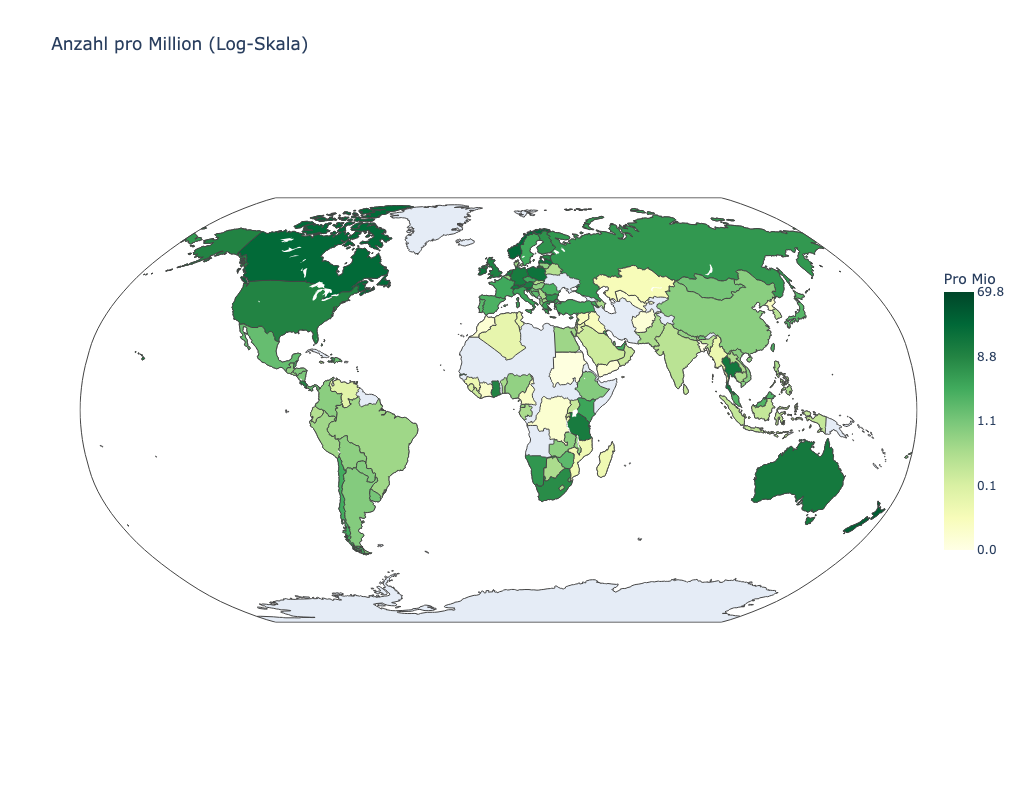

In [83]:
import plotly.express as px
import numpy as np

# Daten vorbereiten
# Wir ignorieren 0-Werte für den Logarithmus
valid_data = final_df[final_df['Count_Per_Mil'] > 0]
min_val = valid_data['Count_Per_Mil'].min()
max_val = valid_data['Count_Per_Mil'].max()

# Logarithmische Grenzwerte für die Farbskala berechnen
zmin = np.log10(min_val)
zmax = np.log10(max_val)

fig = px.choropleth(
    final_df,
    locations="ISO3",
    color="Log_Count",
    hover_name="Country_Clean",
    hover_data={"Log_Count": False, "Count_Per_Mil": ":.2f"},
    color_continuous_scale="YlGn", # Probier mal 'Plasma' oder 'YlOrRd'
    range_color=[zmin, zmax],        # Hier wird die Skala exakt begrenzt
    title="Anzahl pro Million (Log-Skala)",
    height=800, width=1000
)

# Legende mit echten Werten beschriften
# Wir erstellen 5 Ticks zwischen dem Minimum und Maximum
tick_vals = np.linspace(zmin, zmax, 5)
tick_text = [f"{10**val:,.1f}" for val in tick_vals]

fig.update_layout(
    coloraxis_colorbar=dict(
        title="Pro Mio",
        tickvals=tick_vals,
        ticktext=tick_text,
        lenmode="pixels", len=300 # Legende etwas kompakter
    ),
    geo=dict(projection_type='robinson') # Ein weiterer schöner Karten-Stil
)

fig.show()

In [84]:
# 1. Top 10 Länder sortieren
# Wir nehmen nur die relevanten Spalten und sortieren absteigend
top_10_df = final_df[final_df['Count']>10][['Country_Clean', 'Count_Per_Mil', 'Population_2022', 'Count']].sort_values(by='Count_Per_Mil', ascending=False).head(20)

# 2. In HTML umwandeln mit Styling
# Wir nutzen Klassen für ein schöneres Aussehen (optional)
html_table = top_10_df.to_html(
    index=False, 
    justify='center', 
    classes='table table-striped', # Falls du Bootstrap nutzt
    formatters={'Count_Per_Mil': '{:,.2f}'.format} # Schöne Zahlenformatierung
)

# 3. Den HTML-Code in einer Datei speichern
#with open("top_10_countries.html", "w", encoding="utf-8") as f:
#    f.write(html_table)

#print("HTML-Tabelle wurde als 'top_10_countries.html' gespeichert.")

# Falls du die Tabelle direkt im Jupyter Notebook sehen willst:
from IPython.display import HTML
HTML(html_table)

Country_Clean,Count_Per_Mil,Population_2022,Count
New Zealand,33.26,5081700.0,169
Luxembourg,27.56,653103.0,18
Norway,23.82,5457127.0,130
Canada,23.11,38935934.0,900
Latvia,17.03,1879383.0,32
Slovenia,16.57,2112076.0,35
Poland,16.29,36821749.0,600
Ireland,15.54,5212836.0,81
Thailand,13.94,71735329.0,1000
Switzerland,13.67,8777088.0,120
